In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:

df = pd.read_csv('Copia de data_merged.csv')



In [12]:
df.columns

Index(['acousticness', 'danceability', 'duration_ms', 'energy', 'explicit',
       'instrumentalness', 'liveness', 'loudness', 'popularity', 'speechiness',
       'tempo', 'valence', 'year', 'key_0', 'key_1', 'key_2', 'key_3', 'key_4',
       'key_5', 'key_6', 'key_7', 'key_8', 'key_9', 'key_10', 'key_11',
       'minor', 'major', 'acousticness_ar', 'danceability_ar',
       'duration_ms_ar', 'energy_ar', 'instrumentalness_ar', 'liveness_ar',
       'loudness_ar', 'speechiness_ar', 'tempo_ar', 'valence_ar',
       'popularity_ar', 'count', 'key_0_ar', 'key_1_ar', 'key_2_ar',
       'key_3_ar', 'key_4_ar', 'key_5_ar', 'key_6_ar', 'key_7_ar', 'key_8_ar',
       'key_9_ar', 'key_10_ar', 'key_11_ar', 'minor_ar', 'major_ar',
       'acousticness_yr', 'danceability_yr', 'duration_ms_yr', 'energy_yr',
       'instrumentalness_yr', 'liveness_yr', 'loudness_yr', 'speechiness_yr',
       'tempo_yr', 'valence_yr', 'popularity_yr', 'mode', 'key_0_yr',
       'key_1_yr', 'key_2_yr', 'key_3_yr', 'ke

In [13]:
df.shape

(172230, 72)

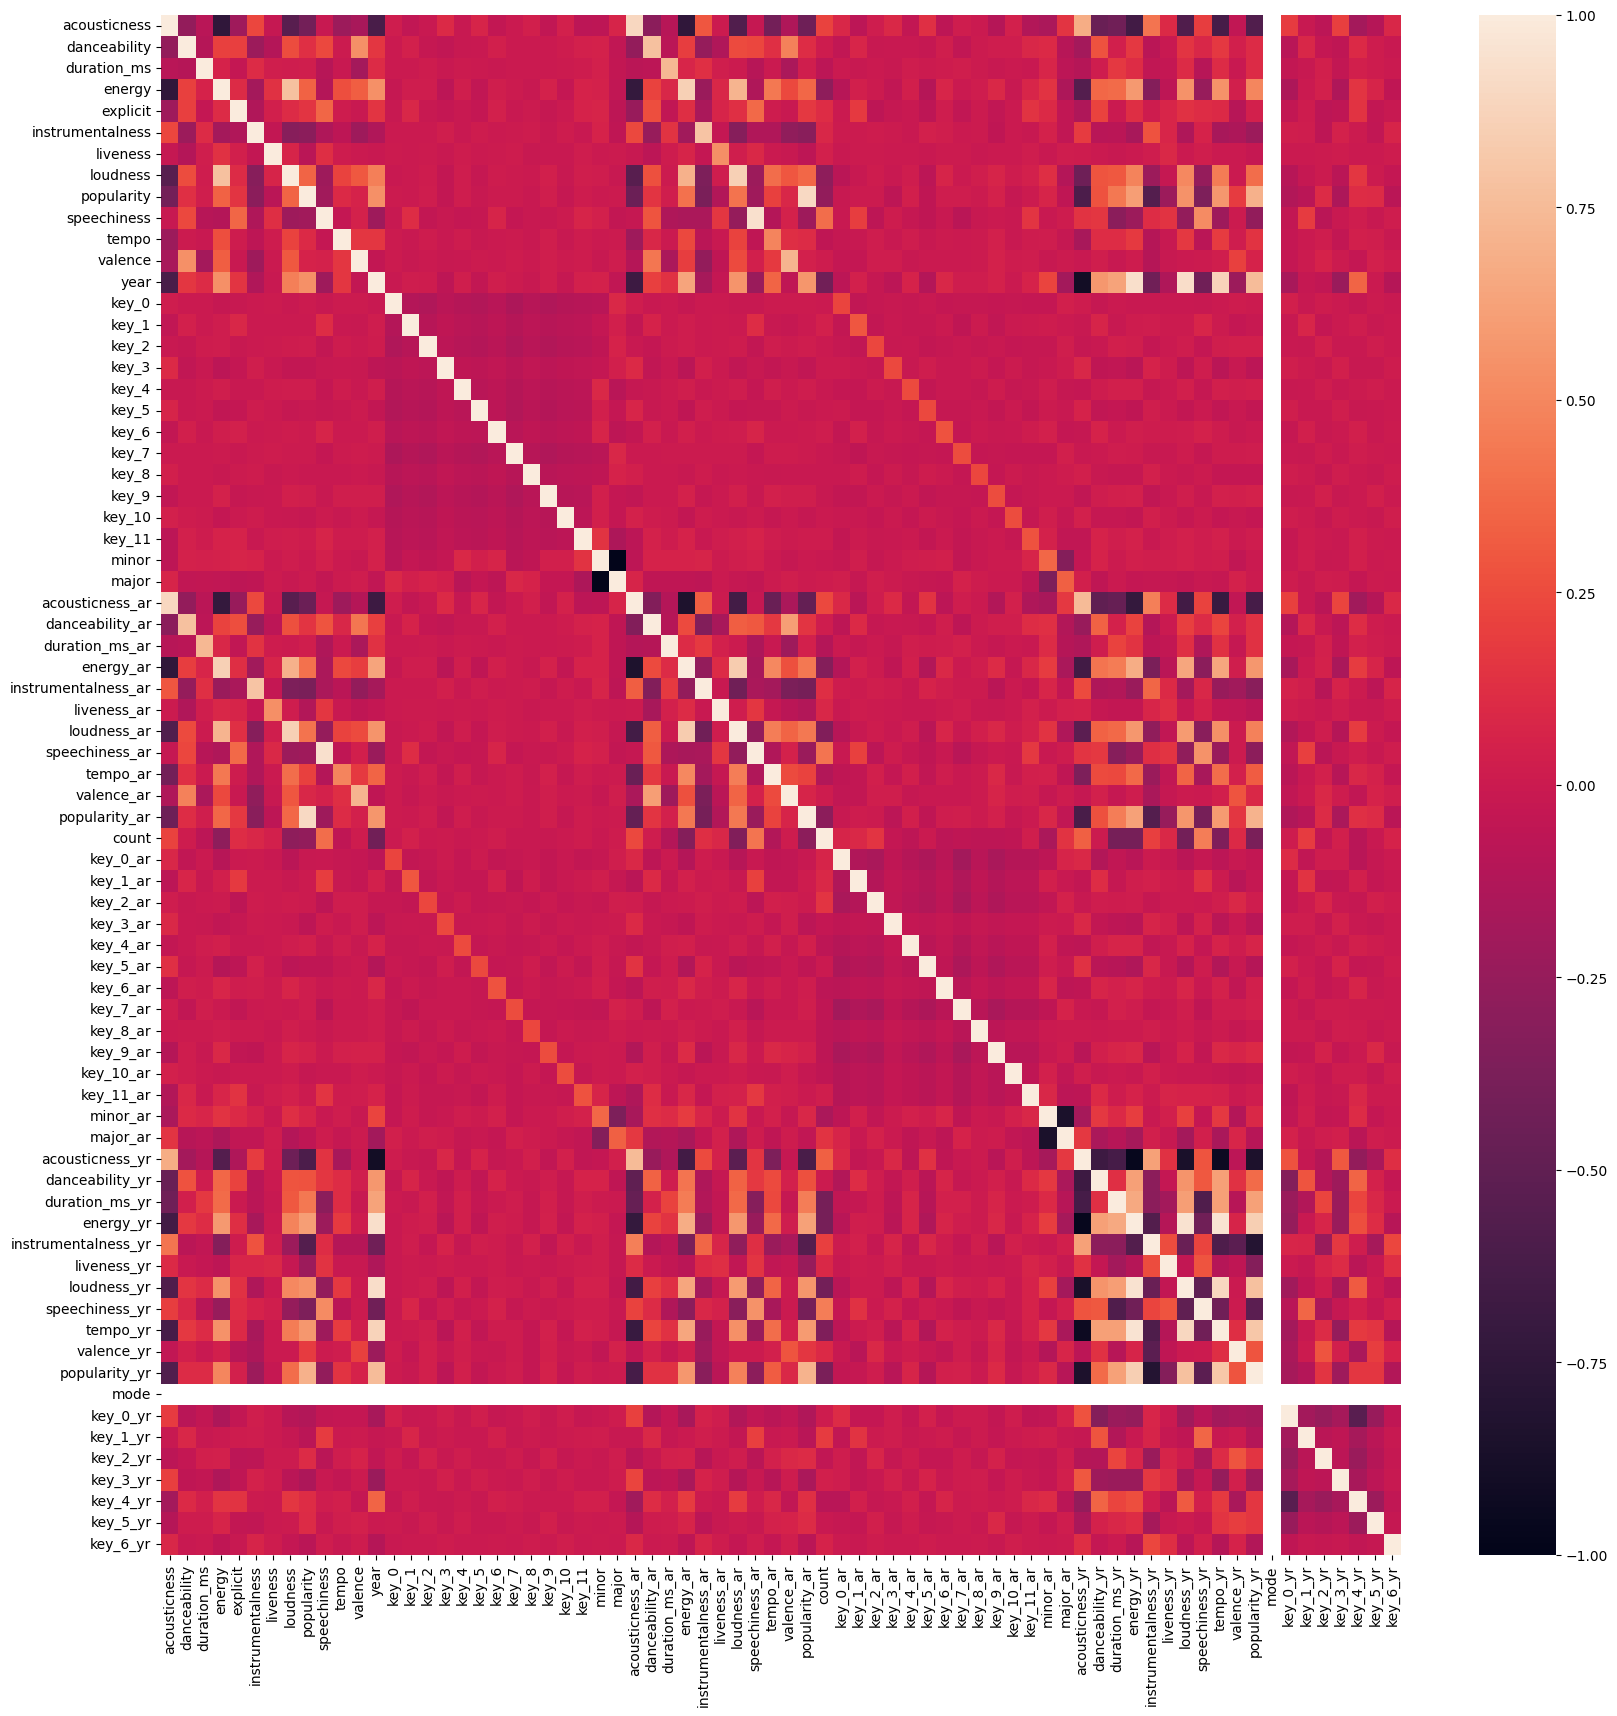

In [17]:
cor = df.corr()
plt.figure(figsize=(20,20))
sns.heatmap(cor)
plt.savefig('corr.png',dpi=400)

In [313]:

def aux(temp):
    if temp<=80:
        return 'lento'
    elif temp <=120:
        return 'moderado'
    return 'rapido'

df['duration_ms']= df['duration_ms']/60000
df['duration_ms_ar'] = df['duration_ms_ar']/60000
df['duration_ms_yr'] = df['duration_ms_yr']/60000

df['energy_ratio_yr'] = df['energy_yr']*df['acousticness_yr']
df['electro_focus_yr'] = (1-df['acousticness_yr'])*df['energy_yr']*df['instrumentalness_yr']
df['vocal_energy_yr'] = (1-df['instrumentalness_yr'])*df['energy_yr']

df['energy_ratio_'] = df['energy']*df['acousticness']
df['electro_focus'] = (1-df['acousticness'])*df['energy']*df['instrumentalness']
df['vocal_energy'] = (1-df['instrumentalness'])*df['energy']

df['energy_ratio_ar'] = df['energy_ar']*df['acousticness_ar']
df['electro_focus_ar'] = (1-df['acousticness_ar'])*df['energy_ar']*df['instrumentalness_ar']
df['vocal_energy_ar'] = (1-df['instrumentalness_ar'])*df['energy_ar']
df['enegy_per_bpm'] = df['energy']/(df['tempo']+1e-6)
df['harmonic_purity'] = df['acousticness']*df['instrumentalness']
df['ryhtmic_pulse'] = (df['tempo']*df['danceability'])/100
df['music_beats_estimated'] = (df['duration_ms']/1000)*(df['tempo']/60)


df['temp_range'] = df['tempo_yr'].apply(aux)
df = pd.get_dummies(df,columns=['temp_range'],prefix='temp')
df[['temp_moderado','temp_rapido']] = df[['temp_moderado','temp_rapido']].astype(int)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 172230 entries, 0 to 172229
Data columns (total 72 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   acousticness         172230 non-null  float64
 1   danceability         172230 non-null  float64
 2   duration_ms          172230 non-null  int64  
 3   energy               172230 non-null  float64
 4   explicit             172230 non-null  int64  
 5   instrumentalness     172230 non-null  float64
 6   liveness             172230 non-null  float64
 7   loudness             172230 non-null  float64
 8   popularity           172230 non-null  int64  
 9   speechiness          172230 non-null  float64
 10  tempo                172230 non-null  float64
 11  valence              172230 non-null  float64
 12  year                 172230 non-null  int64  
 13  key_0                172230 non-null  int64  
 14  key_1                172230 non-null  int64  
 15  key_2            

In [316]:
df.isnull().sum().sum()

np.int64(0)

In [317]:
df['mode'].max()

np.int64(1)

In [318]:
df['mode'].min()

np.int64(1)

In [319]:
df = df.drop(columns=['mode'])
#[f'key_{x}' for x in range(1,12)]+[f'key_{x}_ar' for x in range(0,12)]+[f'key_{x}_yr' for x in range(0,7)]+['key_0']

In [320]:
corr = df.corr()

<Axes: >

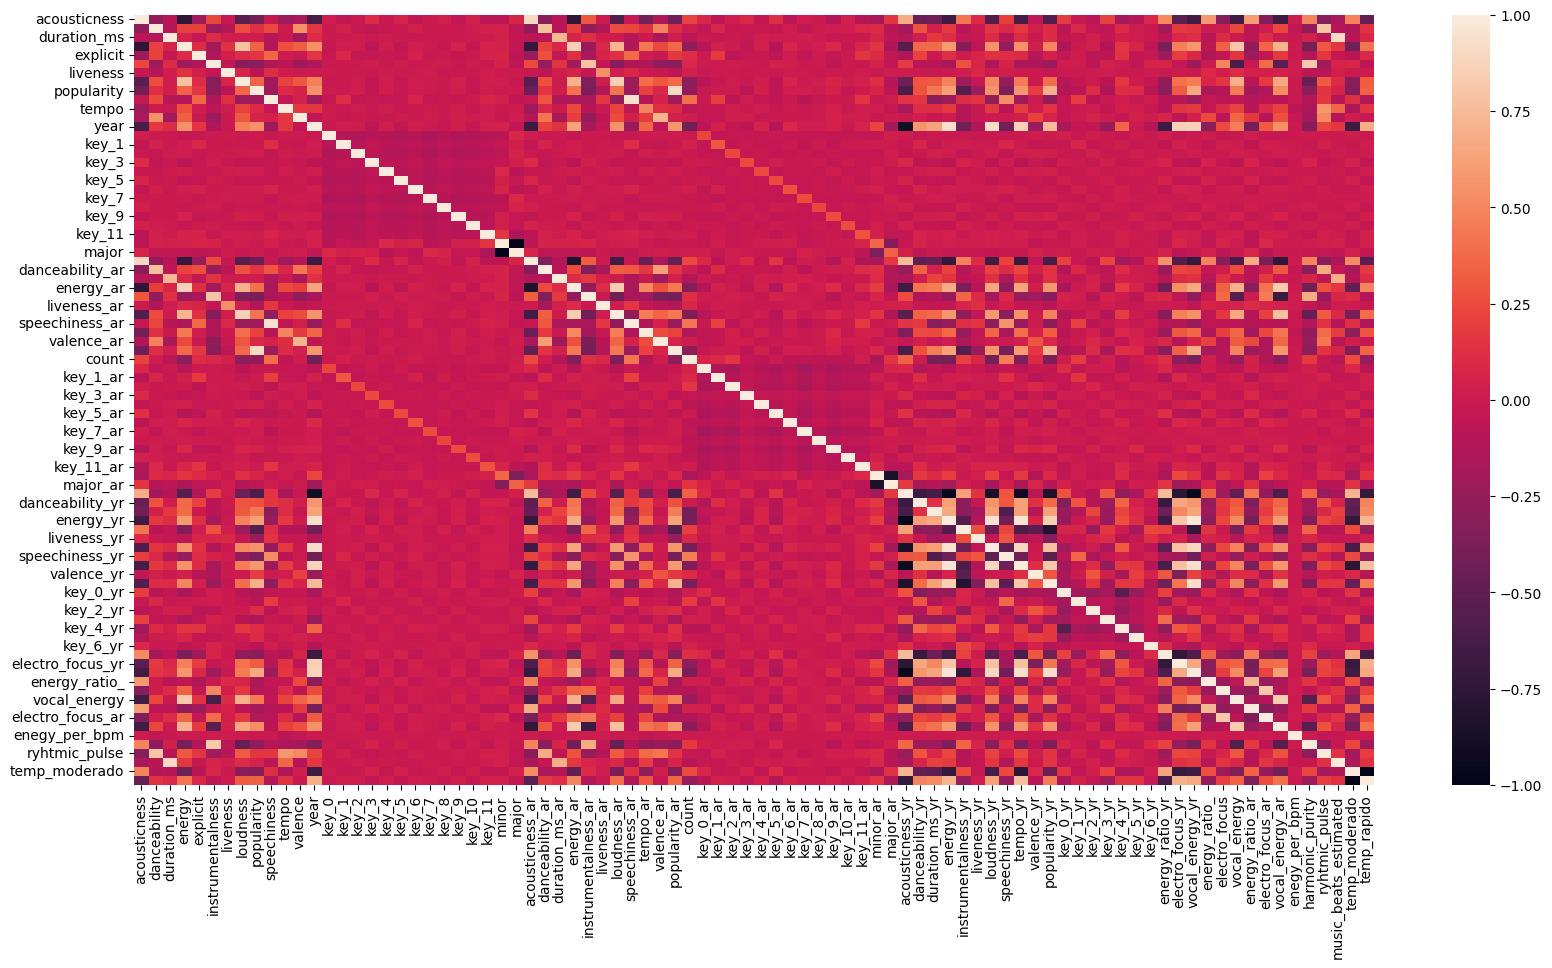

In [321]:
plt.figure(figsize=(20,10))
sns.heatmap(corr)

In [ ]:
terciles = df['popularity'].quantile([0.33, 0.67])
terciles

0.2     0.0
0.4    17.0
0.6    32.0
0.8    46.0
Name: popularity, dtype: float64

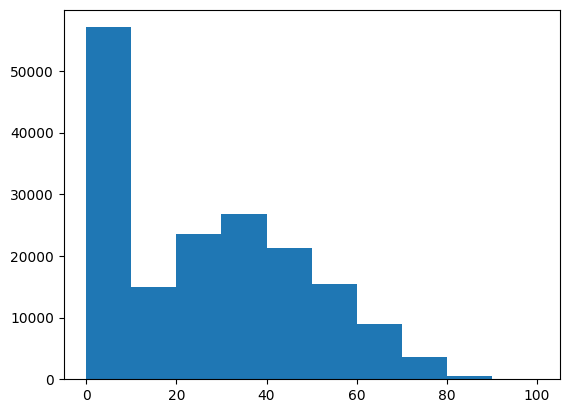

In [30]:
#df['popularity'].plot(kind='hist')
plt.hist(df['popularity'])
plt.savefig('popularity.png',dpi=421)

In [323]:

df_processed = df.copy()

initial_rows = len(df_processed)
df_processed = df_processed.dropna()


def categorize_popularity(popularity):
    if popularity == 0:
        return 0 #no popular
    elif popularity<=20:
        return 1 # baja
    elif popularity <=40:
        return 2 # media
    return 3 # alta

df_processed['popularity_multiclass'] = df_processed['popularity'].apply(categorize_popularity)
print("\nVariable multiclase 3 niveles (popularity_multiclass):")
multiclass_counts = df_processed['popularity_multiclass'].value_counts().sort_index()
multiclass_labels = ['no popular','Baja', 'Media', 'Alta']
for i, (count, label) in enumerate(zip(multiclass_counts, multiclass_labels)):
    print(f"   {i} ({label}): {count} ({count/len(df_processed)*100:.1f}%)")




Variable multiclase 3 niveles (popularity_multiclass):
   0 (no popular): 39729 (23.1%)
   1 (Baja): 34033 (19.8%)
   2 (Media): 51035 (29.6%)
   3 (Alta): 47433 (27.5%)


In [324]:


_X = df_processed.copy()

X = _X.drop(columns=['popularity','popularity_multiclass'])
y_multiclass_3 = df_processed['popularity_multiclass'] 



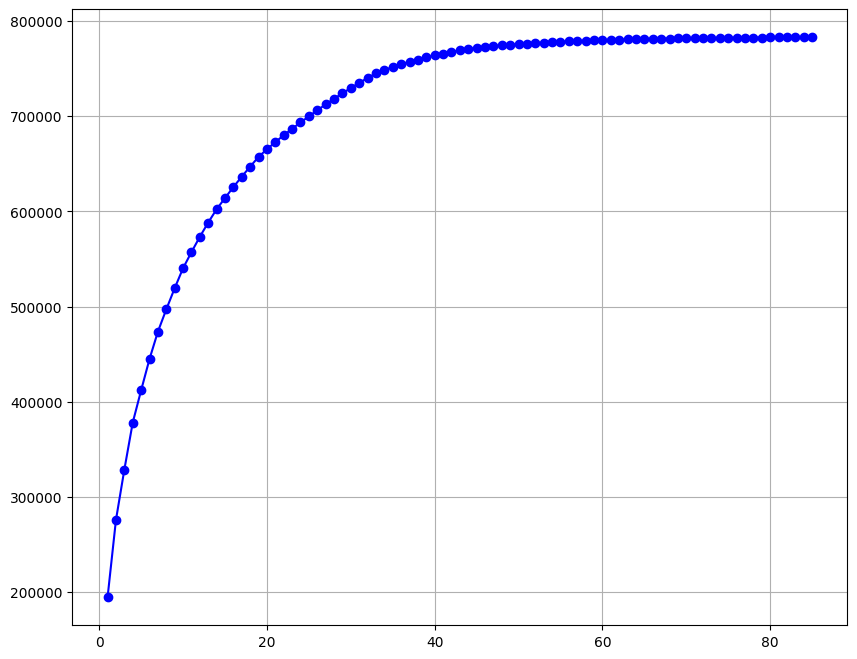

In [325]:
from sklearn.feature_selection import SelectKBest, f_classif
selector = SelectKBest(score_func=f_classif,k='all')
X_new = selector.fit_transform(X,y_multiclass_3)
total_score = selector.scores_
sorted_scoress = np.cumsum(np.sort(total_score)[::-1])
plt.figure(figsize=(10,8))
plt.grid(visible=True)
plt.plot(range(1,X.shape[1]+1),sorted_scoress,'bo-')


In [326]:
selector = SelectKBest(score_func=f_classif,k=40)
X_new = selector.fit_transform(X,y_multiclass_3)
select = selector.get_feature_names_out()
select


array(['acousticness', 'energy', 'explicit', 'instrumentalness',
       'loudness', 'speechiness', 'year', 'acousticness_ar', 'energy_ar',
       'instrumentalness_ar', 'loudness_ar', 'speechiness_ar', 'tempo_ar',
       'popularity_ar', 'count', 'acousticness_yr', 'danceability_yr',
       'duration_ms_yr', 'energy_yr', 'instrumentalness_yr',
       'liveness_yr', 'loudness_yr', 'speechiness_yr', 'tempo_yr',
       'valence_yr', 'popularity_yr', 'key_0_yr', 'key_1_yr', 'key_2_yr',
       'key_4_yr', 'key_5_yr', 'energy_ratio_yr', 'electro_focus_yr',
       'vocal_energy_yr', 'vocal_energy', 'energy_ratio_ar',
       'vocal_energy_ar', 'harmonic_purity', 'temp_moderado',
       'temp_rapido'], dtype=object)

In [327]:
_X=X[select]
y =y_multiclass_3
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, 
)
from sklearn.preprocessing import RobustScaler

In [328]:
scaler1 = RobustScaler()

X_train_reduce, X_test_reduce, y_train_reduce, y_test_reduce = train_test_split(
    _X, y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)
X_train_reduce = scaler1.fit_transform(X_train_reduce)
X_test_scaled = scaler1.transform(X_test_reduce)

# K=40


RandomForest
Best params: {'max_depth': 20, 'n_estimators': 500}
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      7946
           1       0.78      0.82      0.80      6806
           2       0.72      0.78      0.75     10207
           3       0.84      0.72      0.78      9487

    accuracy                           0.81     34446
   macro avg       0.82      0.82      0.82     34446
weighted avg       0.82      0.81      0.81     34446



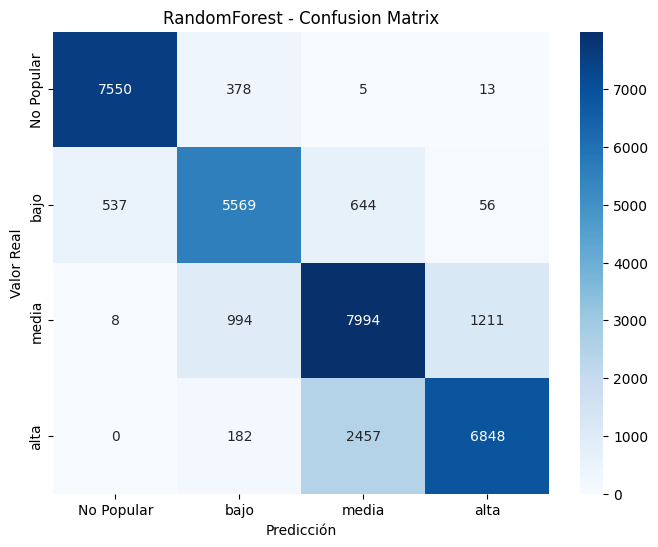


random
              precision    recall  f1-score   support

           0       0.22      0.24      0.23      7946
           1       0.18      0.23      0.21      6806
           2       0.30      0.25      0.27     10207
           3       0.28      0.25      0.26      9487

    accuracy                           0.25     34446
   macro avg       0.25      0.24      0.24     34446
weighted avg       0.25      0.25      0.25     34446



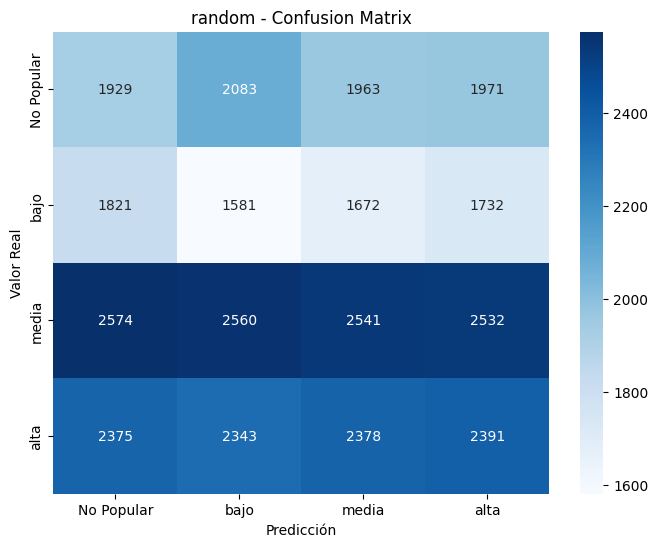

In [329]:

models = {
    'RandomForest': RandomForestClassifier(class_weight='balanced'),

}
param_grids = {
    
    'RandomForest': {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20]
    },
}
results = {}

for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='f1_macro', n_jobs=-1,verbose=2)
    grid.fit(X_train_reduce, y_train_reduce)
    best = grid.best_estimator_
    y_pred = best.predict(X_test_scaled)
    r = classification_report(y_test_reduce, y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    print(r)
    cm = confusion_matrix(y_test_reduce, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Popular', 'bajo','media','alta'],
                yticklabels=['No Popular', 'bajo','media','alta'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()

    y_random = np.random.randint(0,4,size=len(y_test_reduce))
    print(f"\nrandom")
    r = classification_report(y_test_reduce, y_random)
    print(r)
    cm = confusion_matrix(y_test_reduce, y_random)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Popular', 'bajo','media','alta'],
                yticklabels=['No Popular', 'bajo','media','alta'])
    plt.title(f'random - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()
    results[name] = grid.best_params_

In [341]:
featurers = best.feature_importances_

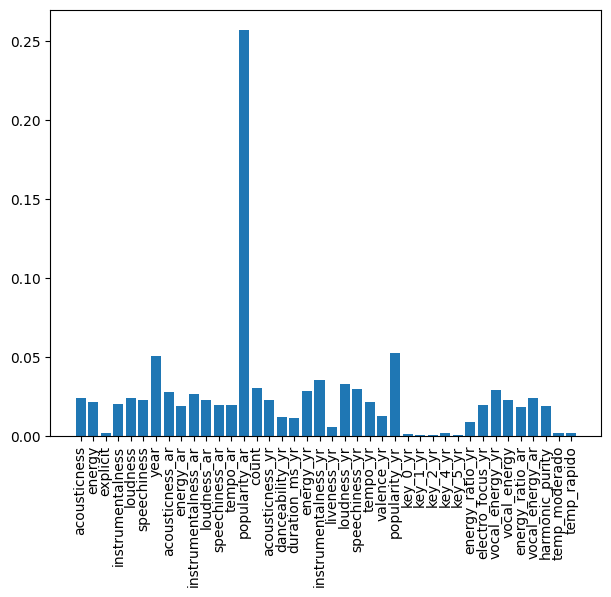

In [355]:
plt.bar(x=_X.columns,height=featurers)
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

In [356]:
_X.columns

Index(['acousticness', 'energy', 'explicit', 'instrumentalness', 'loudness',
       'speechiness', 'year', 'acousticness_ar', 'energy_ar',
       'instrumentalness_ar', 'loudness_ar', 'speechiness_ar', 'tempo_ar',
       'popularity_ar', 'count', 'acousticness_yr', 'danceability_yr',
       'duration_ms_yr', 'energy_yr', 'instrumentalness_yr', 'liveness_yr',
       'loudness_yr', 'speechiness_yr', 'tempo_yr', 'valence_yr',
       'popularity_yr', 'key_0_yr', 'key_1_yr', 'key_2_yr', 'key_4_yr',
       'key_5_yr', 'energy_ratio_yr', 'electro_focus_yr', 'vocal_energy_yr',
       'vocal_energy', 'energy_ratio_ar', 'vocal_energy_ar', 'harmonic_purity',
       'temp_moderado', 'temp_rapido'],
      dtype='object')

# K=30



RandomForest
Best params: {'max_depth': 20, 'n_estimators': 500}
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      7946
           1       0.78      0.82      0.80      6806
           2       0.72      0.79      0.75     10207
           3       0.84      0.72      0.78      9487

    accuracy                           0.81     34446
   macro avg       0.82      0.82      0.82     34446
weighted avg       0.82      0.81      0.81     34446



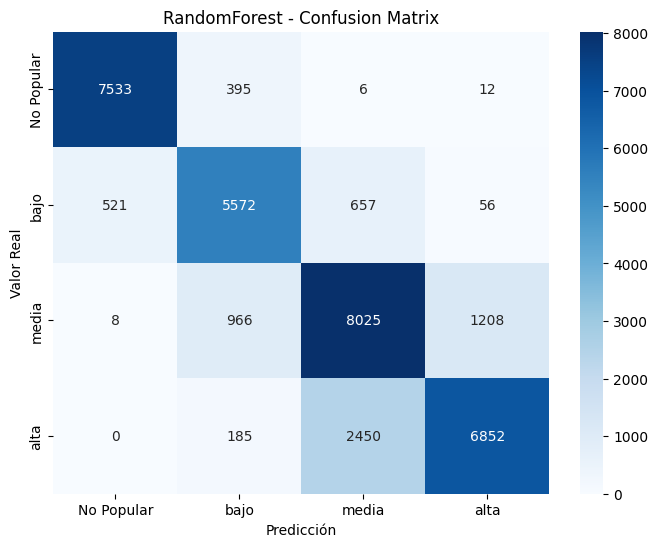


random
              precision    recall  f1-score   support

           0       0.23      0.25      0.24      7946
           1       0.20      0.25      0.22      6806
           2       0.29      0.25      0.27     10207
           3       0.27      0.24      0.25      9487

    accuracy                           0.25     34446
   macro avg       0.25      0.25      0.24     34446
weighted avg       0.25      0.25      0.25     34446



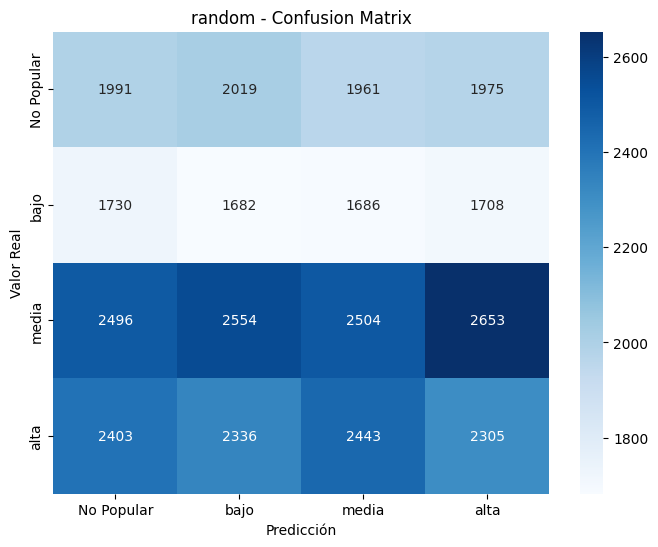

In [307]:
selector = SelectKBest(score_func=f_classif,k=30)
X_new = selector.fit_transform(X,y_multiclass_3)
select = selector.get_feature_names_out()
select
_X=X[select]
y =y_multiclass_3

scaler1 = RobustScaler()

X_train_reduce, X_test_reduce, y_train_reduce, y_test_reduce = train_test_split(
    _X, y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)
X_train_reduce = scaler1.fit_transform(X_train_reduce)
X_test_scaled = scaler1.transform(X_test_reduce)

models = {
    'RandomForest': RandomForestClassifier(class_weight='balanced'),

}
param_grids = {
    
    'RandomForest': {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20]
    },
}
results = {}

for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='f1_macro', n_jobs=-1)
    grid.fit(X_train_reduce, y_train_reduce)
    best = grid.best_estimator_
    y_pred = best.predict(X_test_scaled)
    r = classification_report(y_test_reduce, y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    print(r)
    cm = confusion_matrix(y_test_reduce, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Popular', 'bajo','media','alta'],
                yticklabels=['No Popular', 'bajo','media','alta'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()

    y_random = np.random.randint(0,4,size=len(y_test_reduce))
    print(f"\nrandom")
    r = classification_report(y_test_reduce, y_random)
    print(r)
    cm = confusion_matrix(y_test_reduce, y_random)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Popular', 'bajo','media','alta'],
                yticklabels=['No Popular', 'bajo','media','alta'])
    plt.title(f'random - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()
    results[name] = grid.best_params_

# K=20


RandomForest
Best params: {'max_depth': 20, 'n_estimators': 300}
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      7946
           1       0.78      0.81      0.80      6806
           2       0.72      0.78      0.75     10207
           3       0.83      0.72      0.77      9487

    accuracy                           0.81     34446
   macro avg       0.82      0.81      0.81     34446
weighted avg       0.81      0.81      0.81     34446



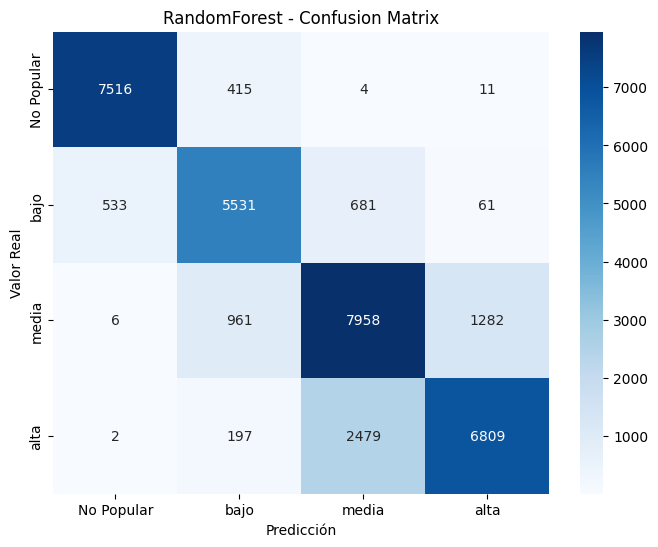


random
              precision    recall  f1-score   support

           0       0.23      0.25      0.24      7946
           1       0.20      0.25      0.22      6806
           2       0.30      0.25      0.27     10207
           3       0.28      0.25      0.26      9487

    accuracy                           0.25     34446
   macro avg       0.25      0.25      0.25     34446
weighted avg       0.26      0.25      0.25     34446



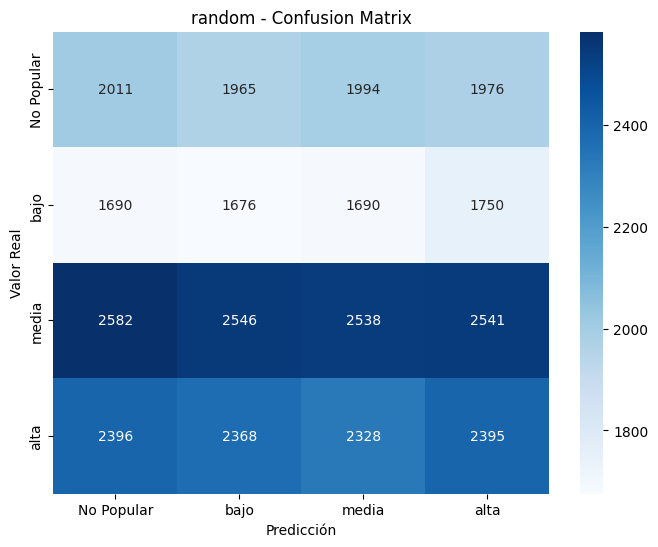

In [308]:
selector = SelectKBest(score_func=f_classif,k=20)
X_new = selector.fit_transform(X,y_multiclass_3)
select = selector.get_feature_names_out()
select
_X=X[select]
y =y_multiclass_3

scaler1 = RobustScaler()

X_train_reduce, X_test_reduce, y_train_reduce, y_test_reduce = train_test_split(
    _X, y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)
X_train_reduce = scaler1.fit_transform(X_train_reduce)
X_test_scaled = scaler1.transform(X_test_reduce)

models = {
    'RandomForest': RandomForestClassifier(class_weight='balanced'),

}
param_grids = {
    
    'RandomForest': {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20]
    },
}
results = {}

for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='f1_macro', n_jobs=-1)
    grid.fit(X_train_reduce, y_train_reduce)
    best = grid.best_estimator_
    y_pred = best.predict(X_test_scaled)
    r = classification_report(y_test_reduce, y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    print(r)
    cm = confusion_matrix(y_test_reduce, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Popular', 'bajo','media','alta'],
                yticklabels=['No Popular', 'bajo','media','alta'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()

    y_random = np.random.randint(0,4,size=len(y_test_reduce))
    print(f"\nrandom")
    r = classification_report(y_test_reduce, y_random)
    print(r)
    cm = confusion_matrix(y_test_reduce, y_random)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Popular', 'bajo','media','alta'],
                yticklabels=['No Popular', 'bajo','media','alta'])
    plt.title(f'random - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()
    results[name] = grid.best_params_

# k=10


RandomForest
Best params: {'max_depth': 20, 'n_estimators': 500}
              precision    recall  f1-score   support

           0       0.93      0.94      0.94      7946
           1       0.76      0.82      0.79      6806
           2       0.71      0.77      0.74     10207
           3       0.83      0.71      0.76      9487

    accuracy                           0.80     34446
   macro avg       0.81      0.81      0.81     34446
weighted avg       0.80      0.80      0.80     34446



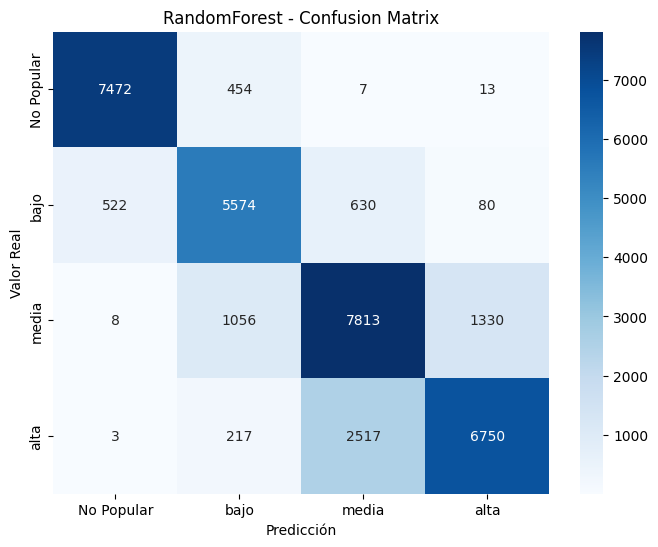


random
              precision    recall  f1-score   support

           0       0.23      0.25      0.24      7946
           1       0.20      0.25      0.22      6806
           2       0.30      0.25      0.27     10207
           3       0.28      0.25      0.26      9487

    accuracy                           0.25     34446
   macro avg       0.25      0.25      0.25     34446
weighted avg       0.26      0.25      0.25     34446



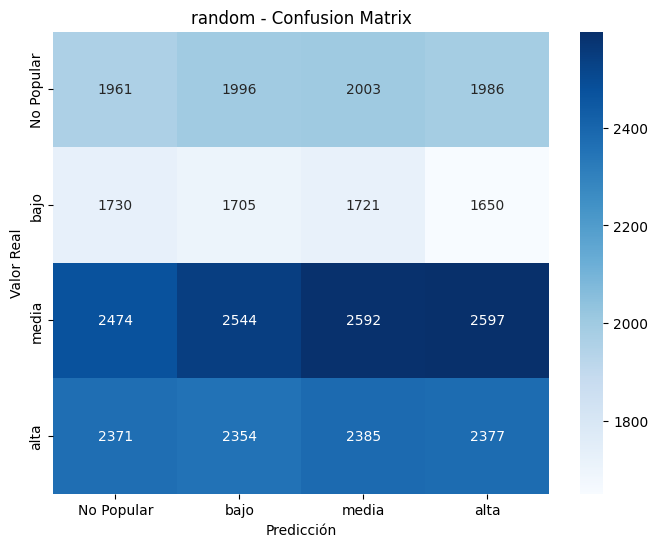

In [309]:
selector = SelectKBest(score_func=f_classif,k=10)
X_new = selector.fit_transform(X,y_multiclass_3)
select = selector.get_feature_names_out()
select
_X=X[select]
y =y_multiclass_3

scaler1 = RobustScaler()

X_train_reduce, X_test_reduce, y_train_reduce, y_test_reduce = train_test_split(
    _X, y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)
X_train_reduce = scaler1.fit_transform(X_train_reduce)
X_test_scaled = scaler1.transform(X_test_reduce)

models = {
    'RandomForest': RandomForestClassifier(class_weight='balanced'),

}
param_grids = {
    
    'RandomForest': {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20]
    },
}
results = {}

for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='f1_macro', n_jobs=-1)
    grid.fit(X_train_reduce, y_train_reduce)
    best = grid.best_estimator_
    y_pred = best.predict(X_test_scaled)
    r = classification_report(y_test_reduce, y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    print(r)
    cm = confusion_matrix(y_test_reduce, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Popular', 'bajo','media','alta'],
                yticklabels=['No Popular', 'bajo','media','alta'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()

    y_random = np.random.randint(0,4,size=len(y_test_reduce))
    print(f"\nrandom")
    r = classification_report(y_test_reduce, y_random)
    print(r)
    cm = confusion_matrix(y_test_reduce, y_random)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Popular', 'bajo','media','alta'],
                yticklabels=['No Popular', 'bajo','media','alta'])
    plt.title(f'random - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()
    results[name] = grid.best_params_

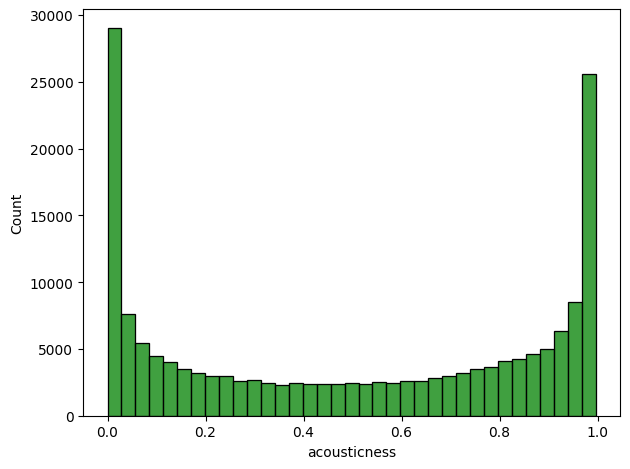

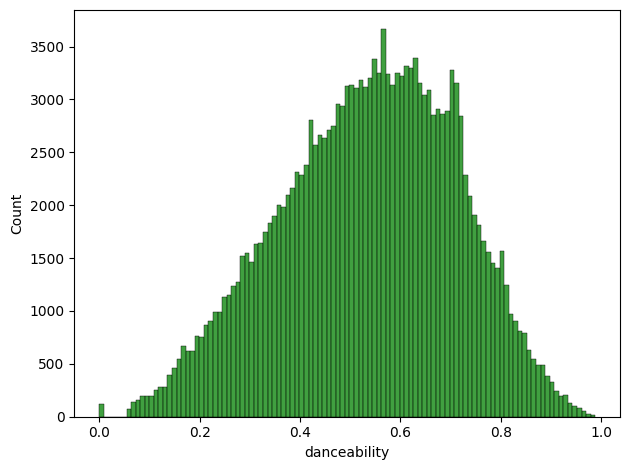

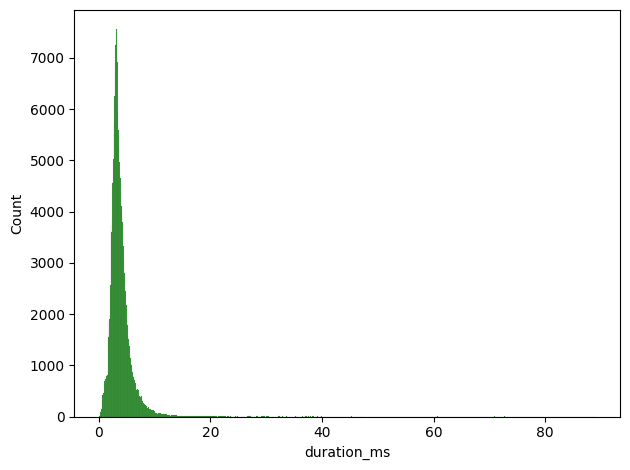

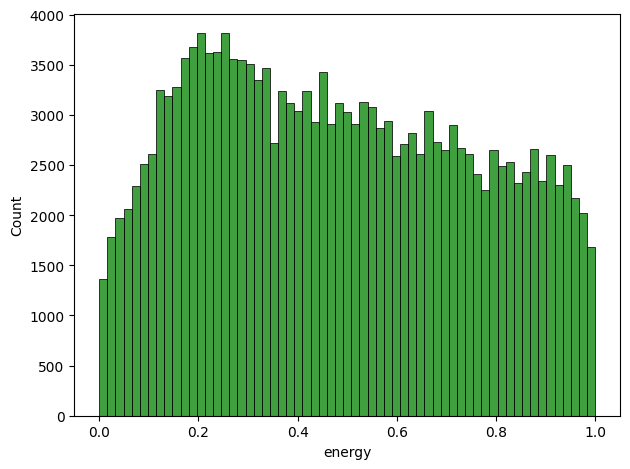

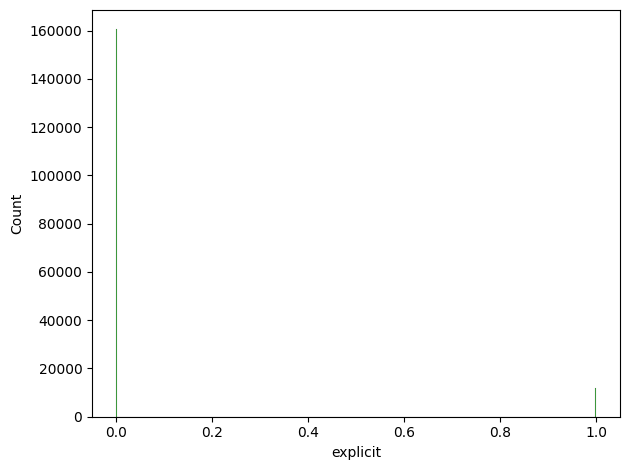

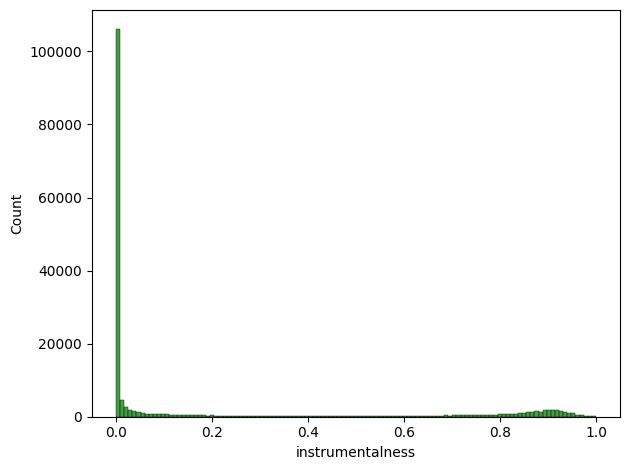

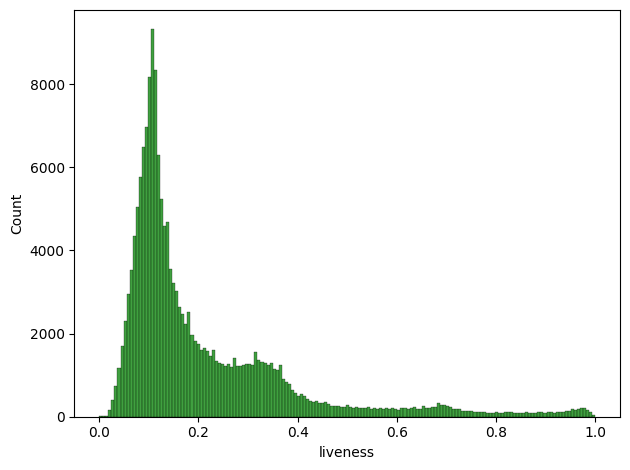

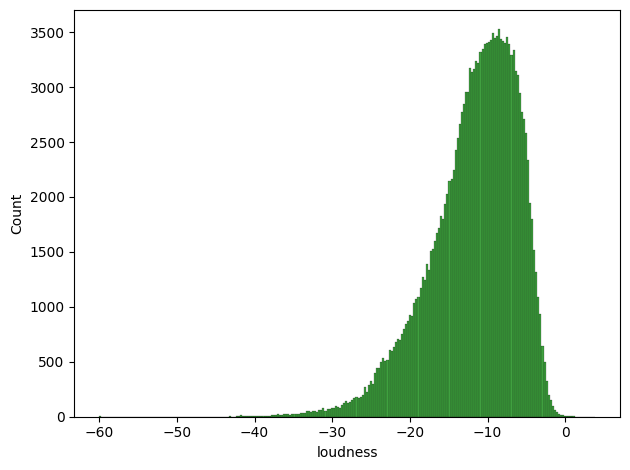

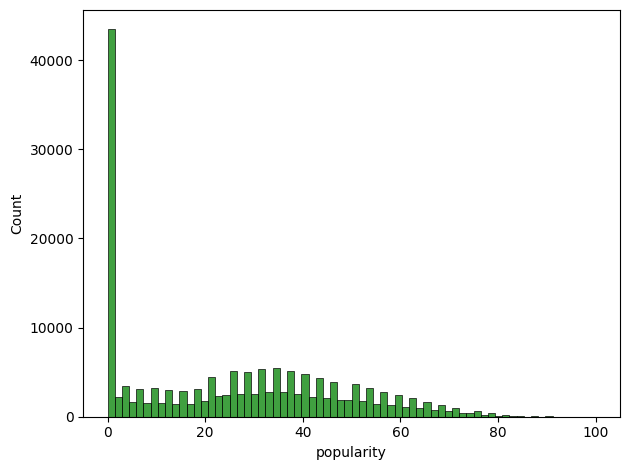

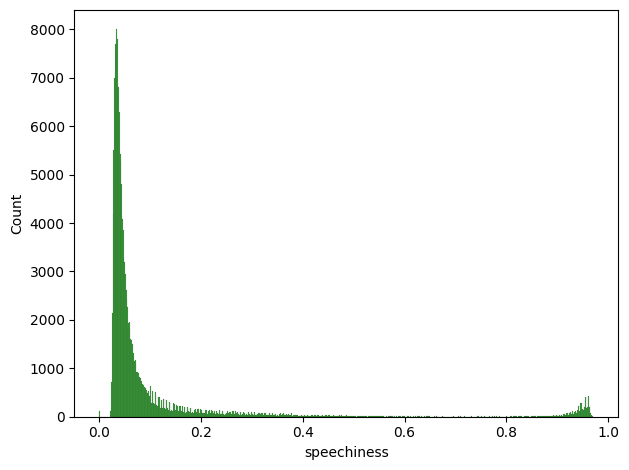

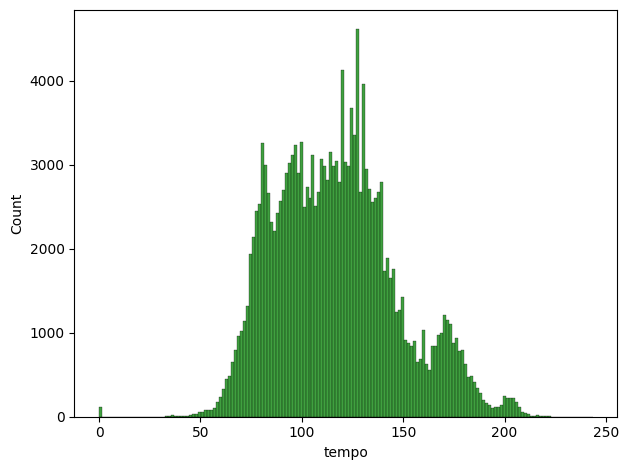

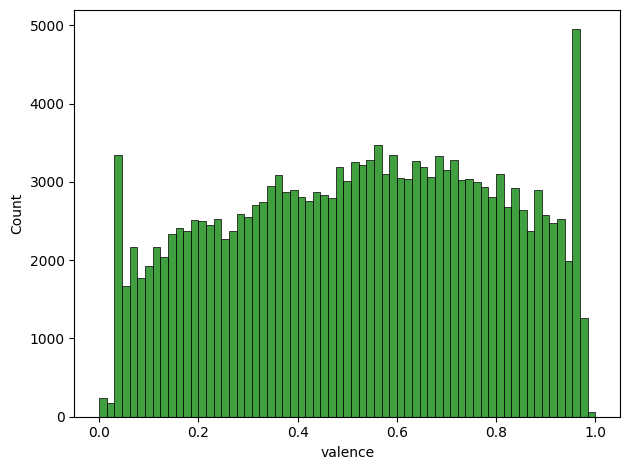

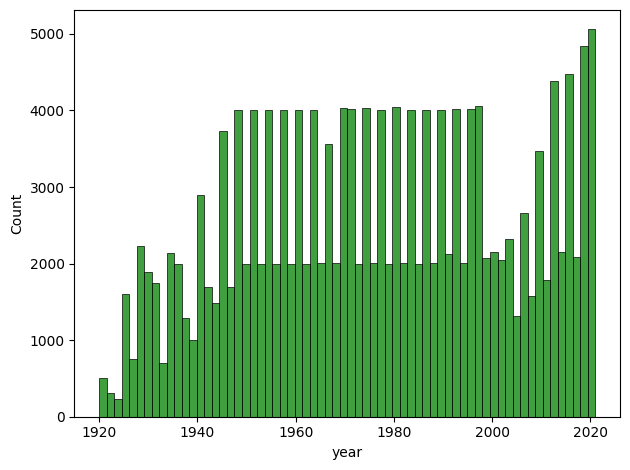

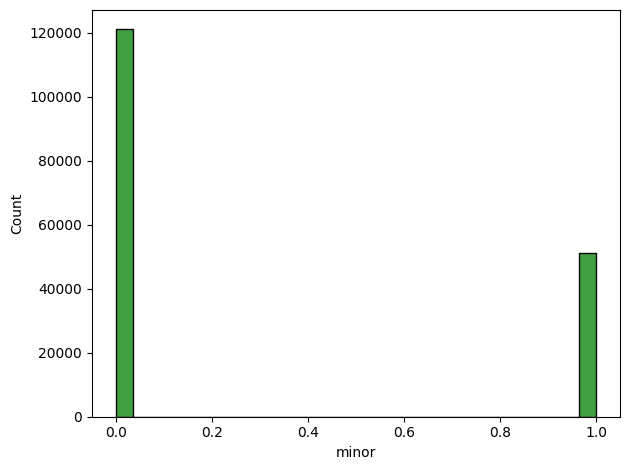

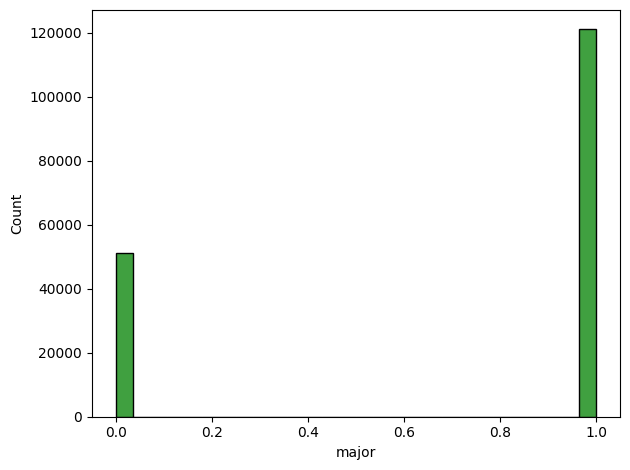

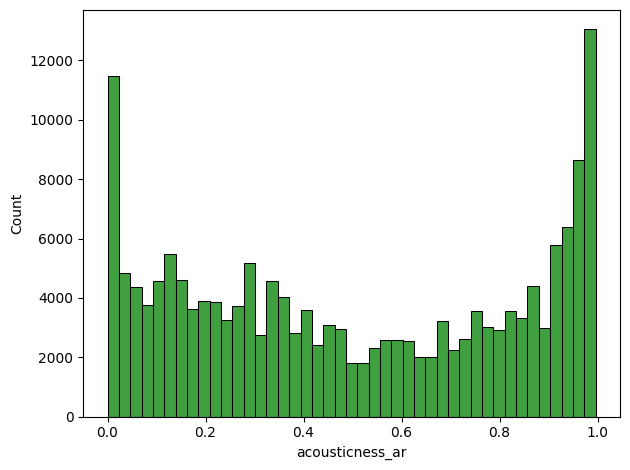

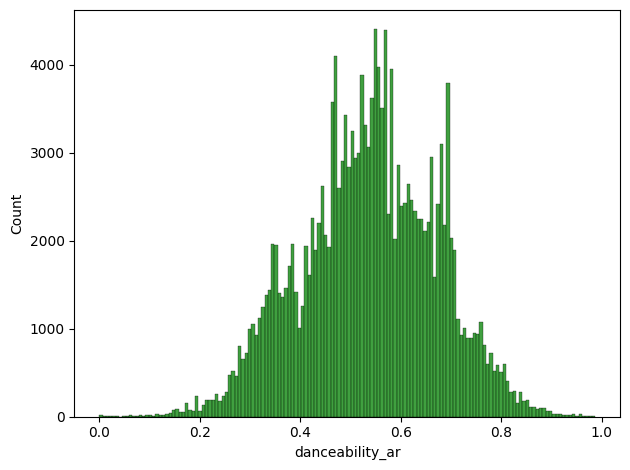

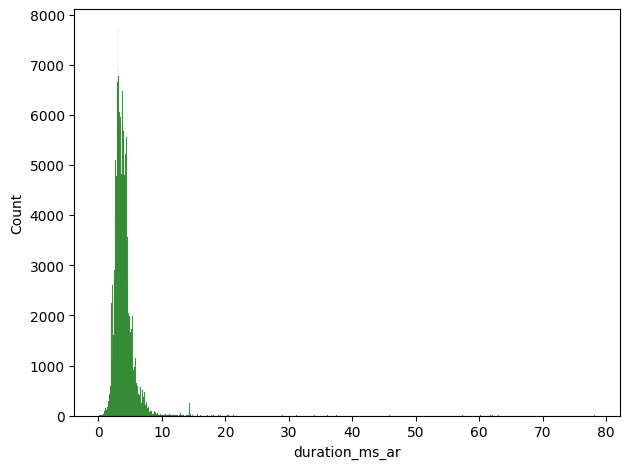

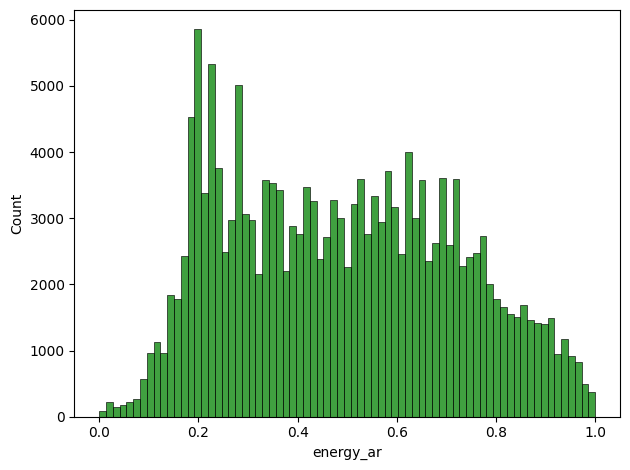

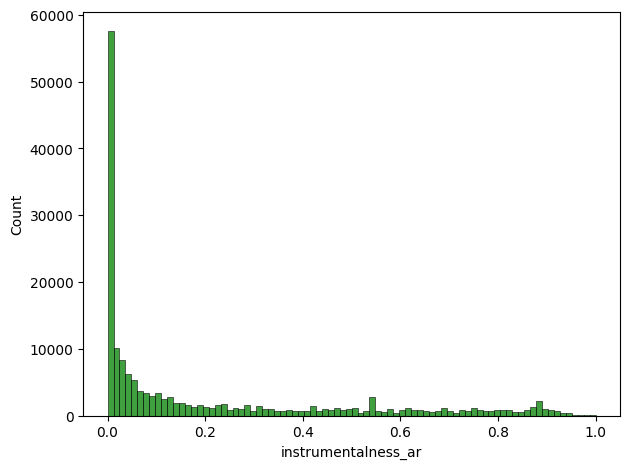

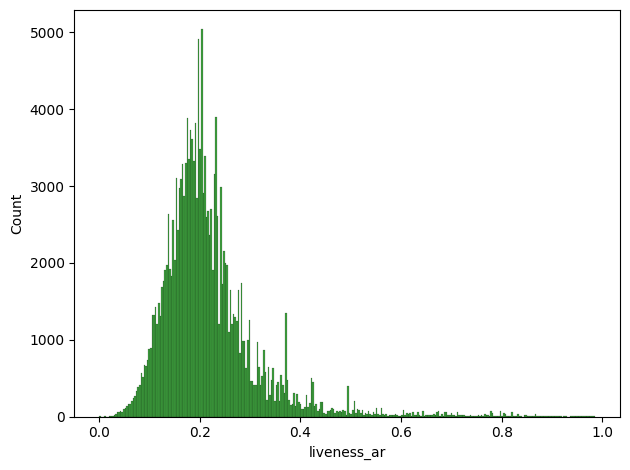

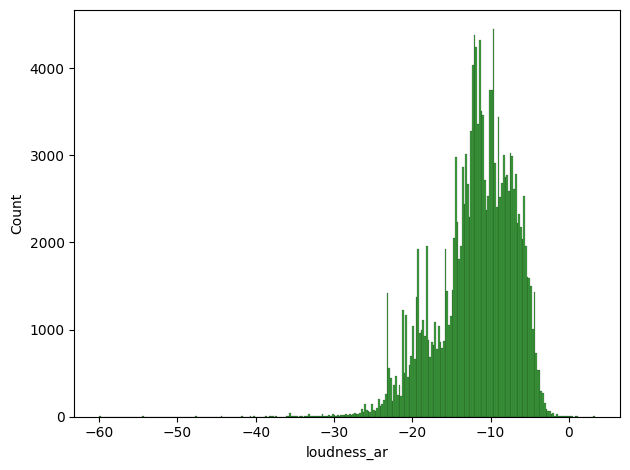

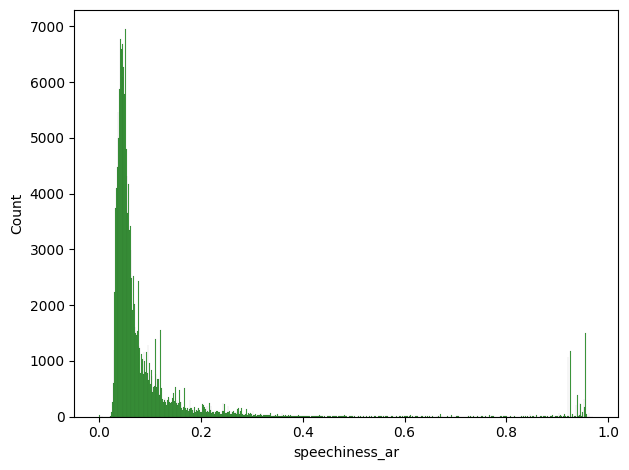

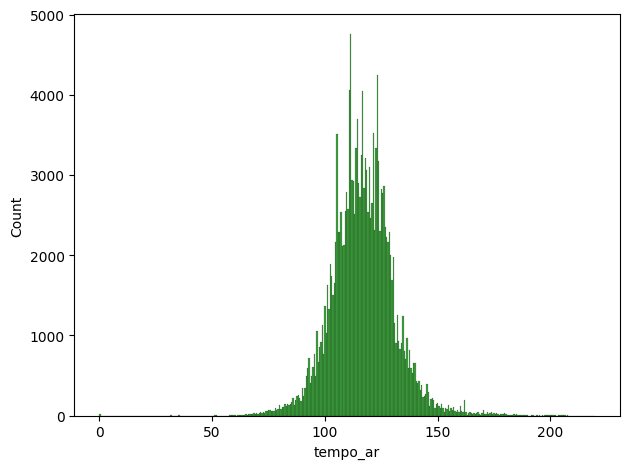

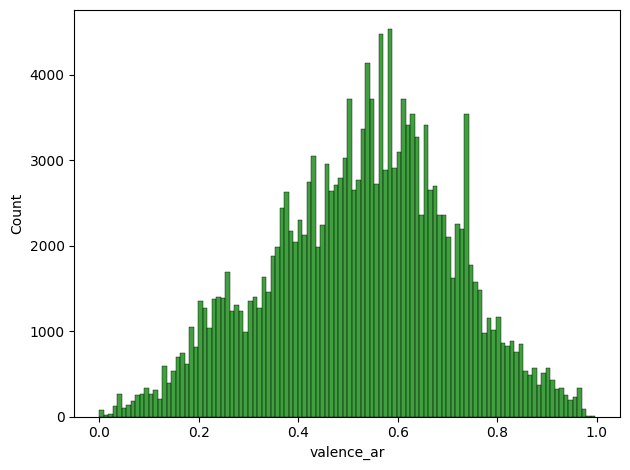

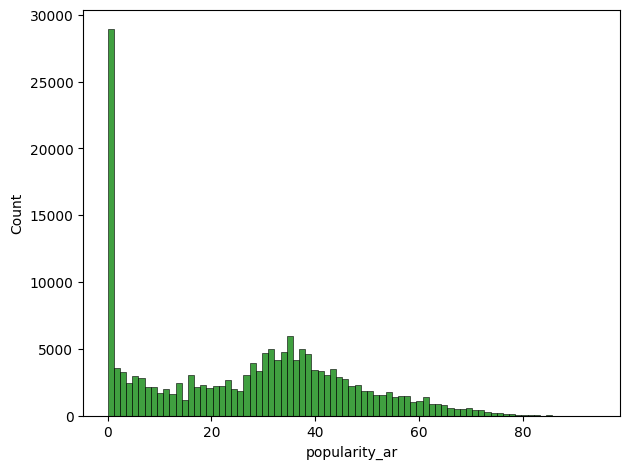

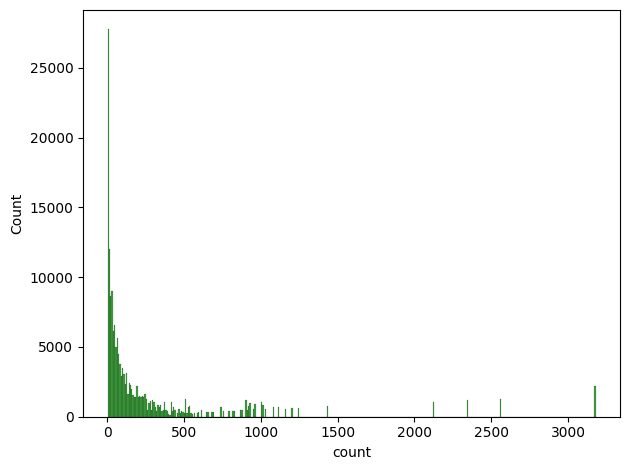

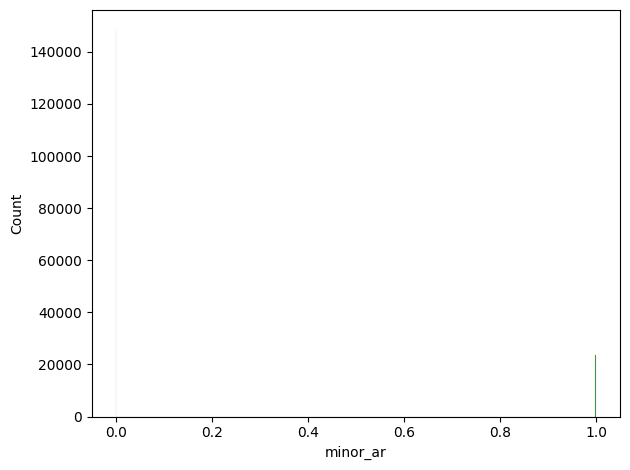

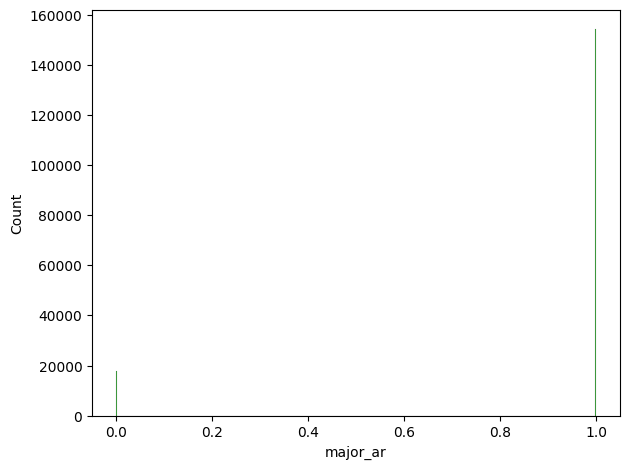

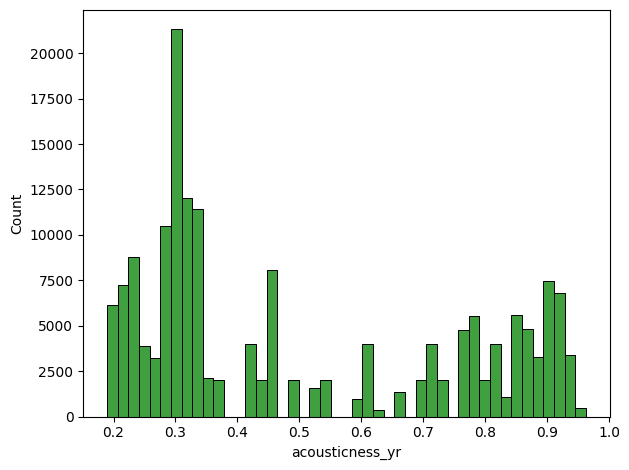

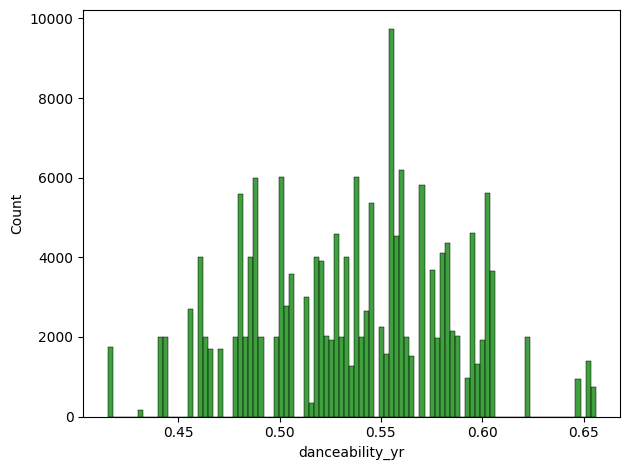

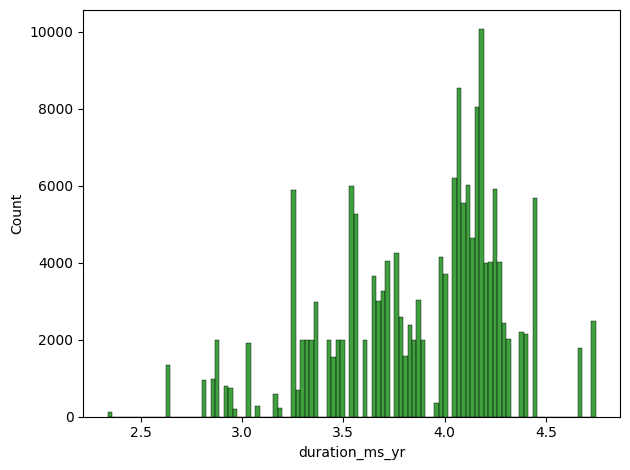

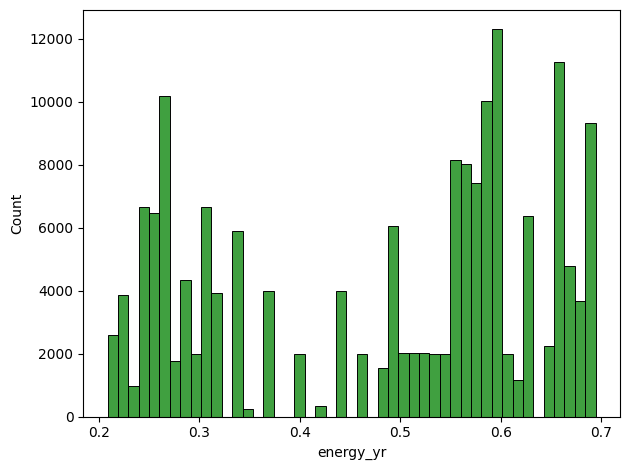

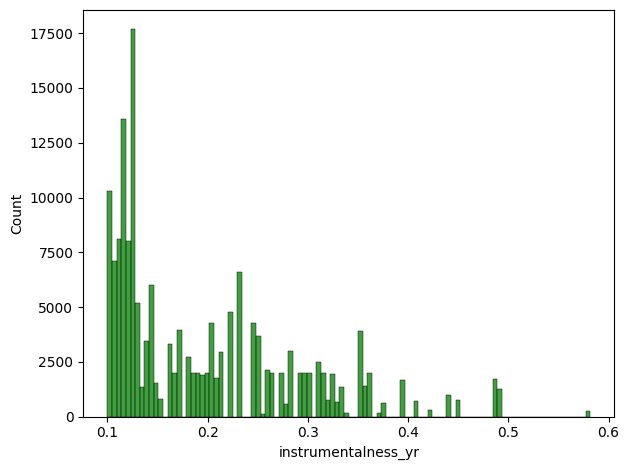

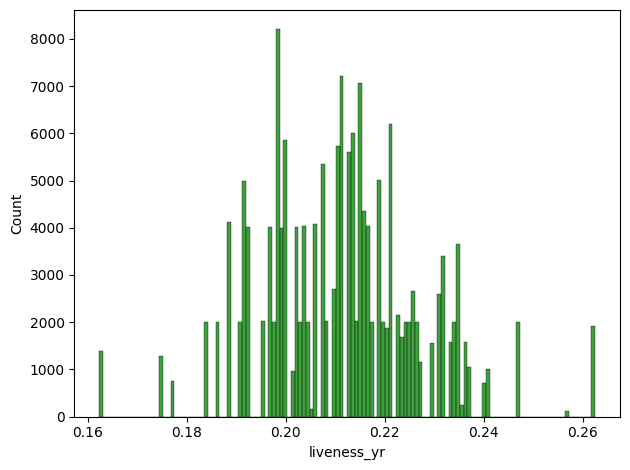

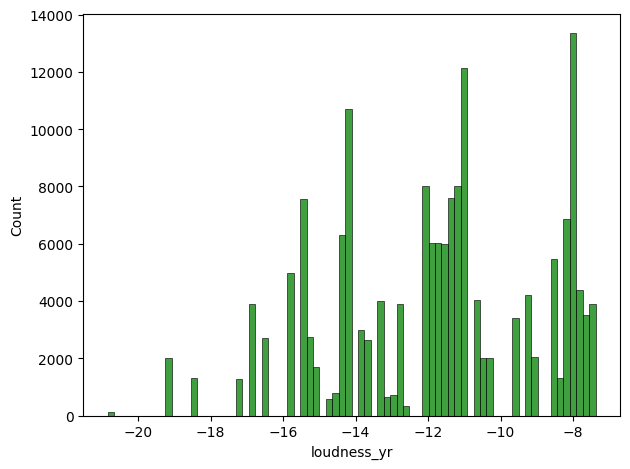

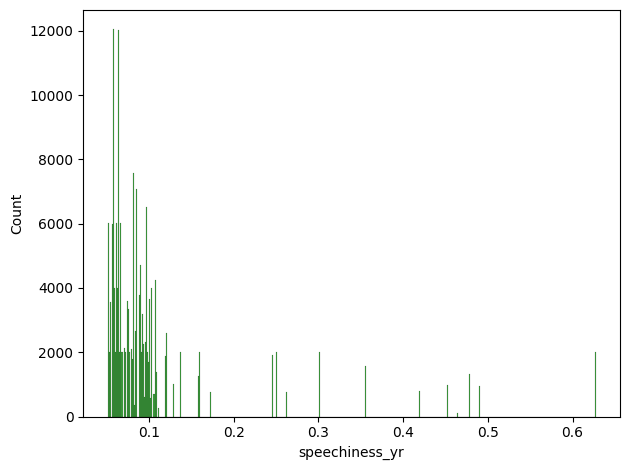

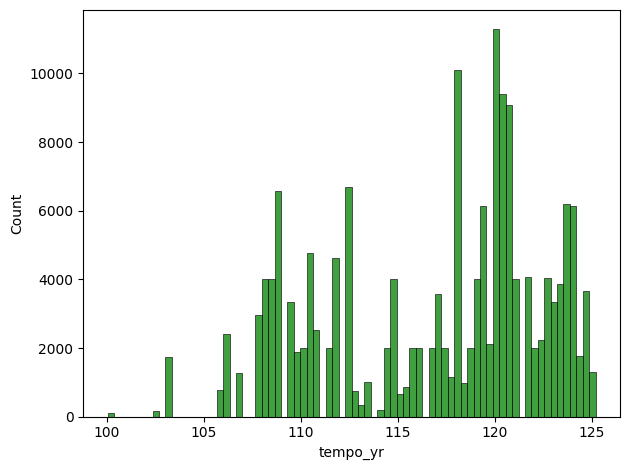

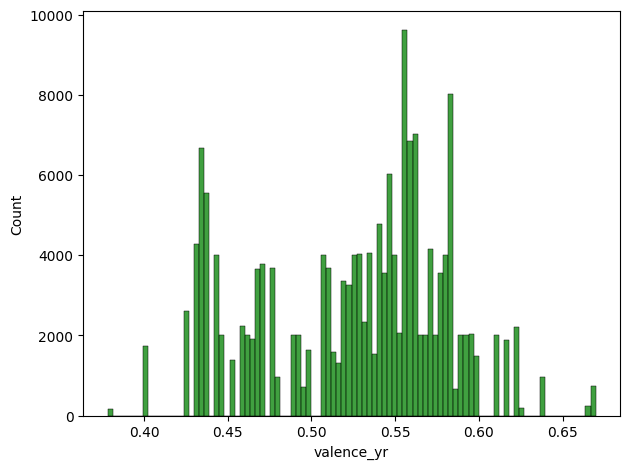

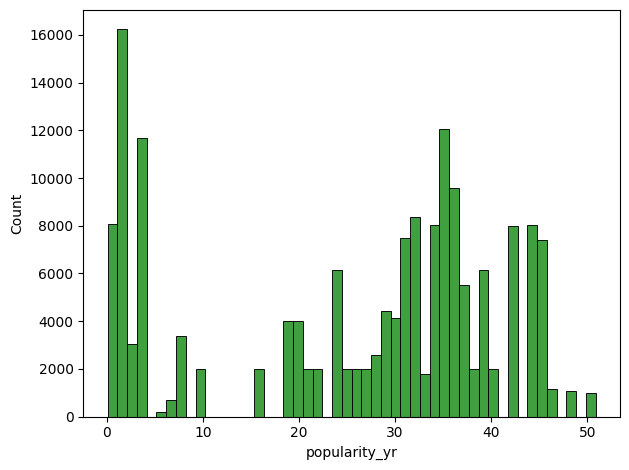

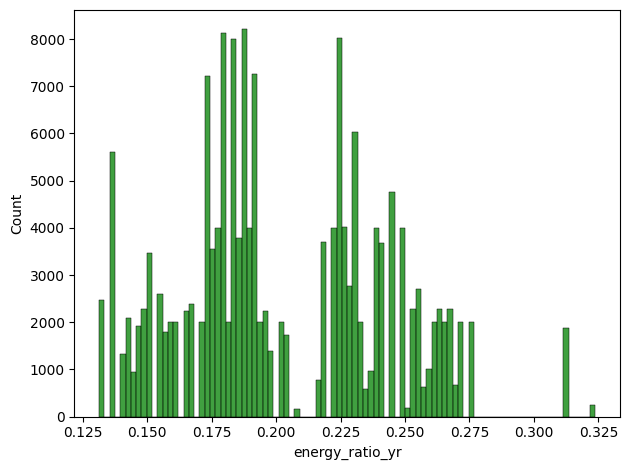

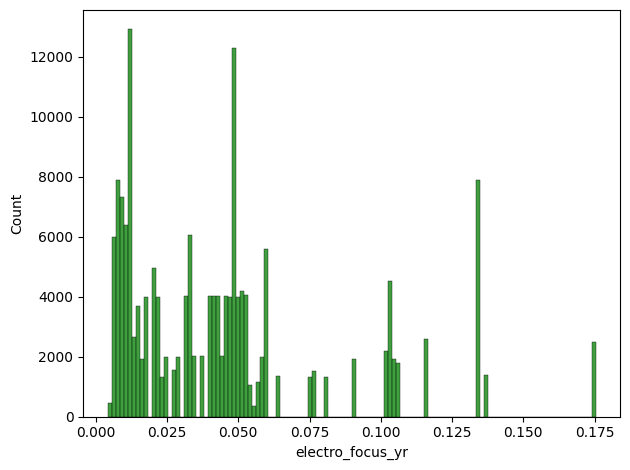

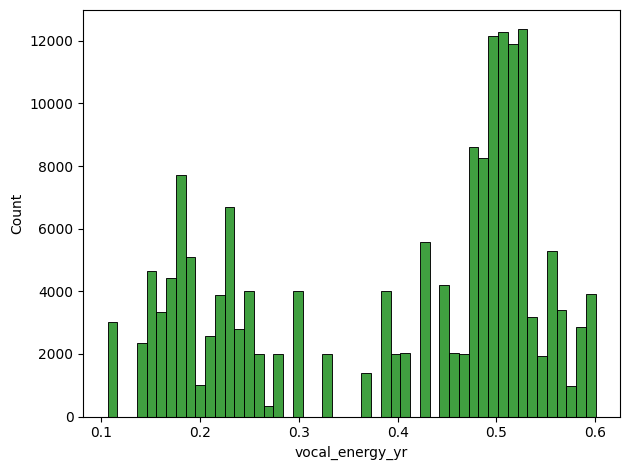

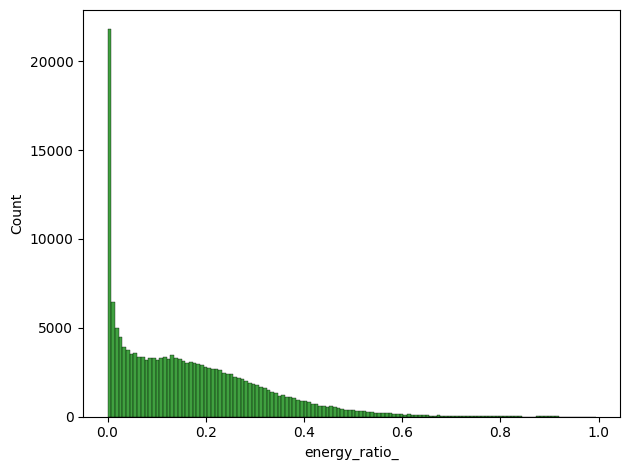

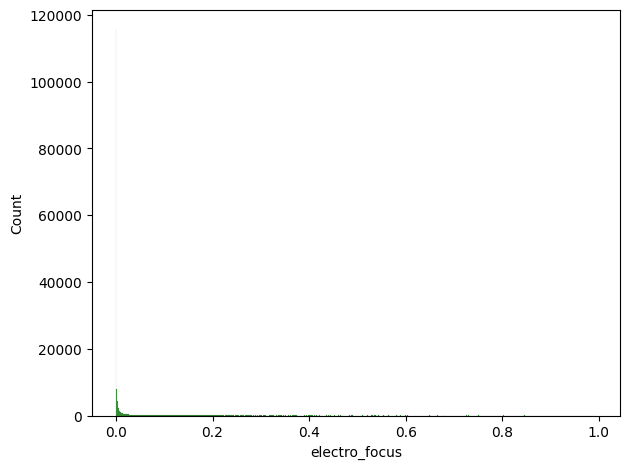

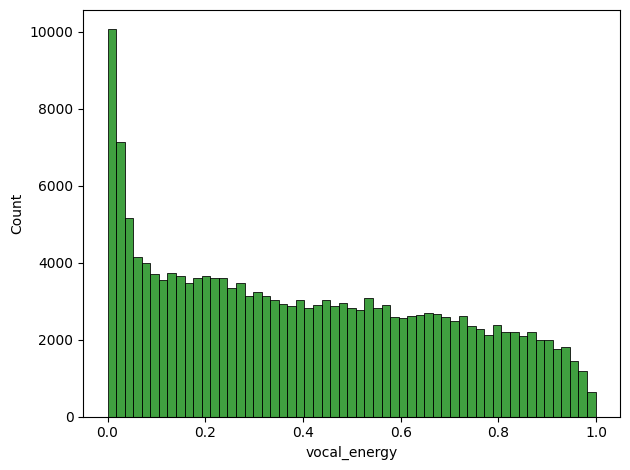

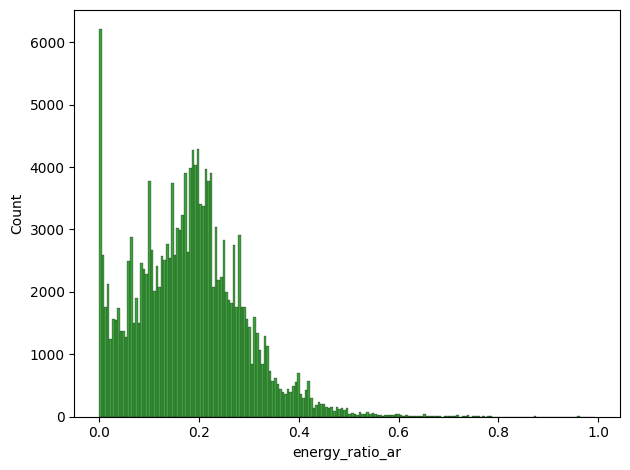

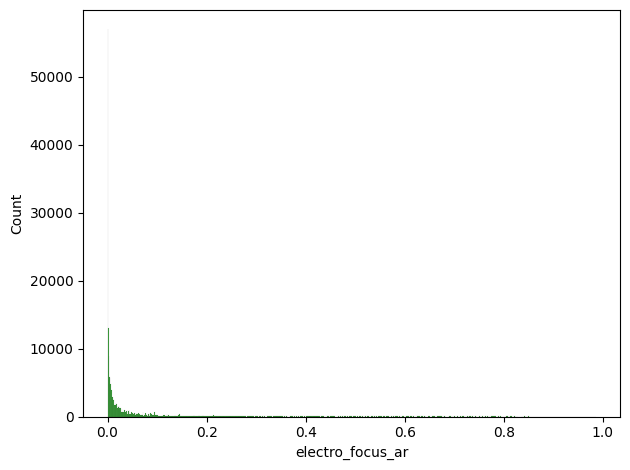

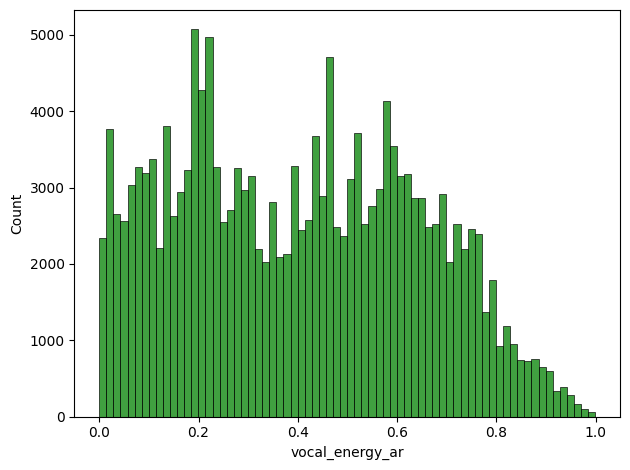

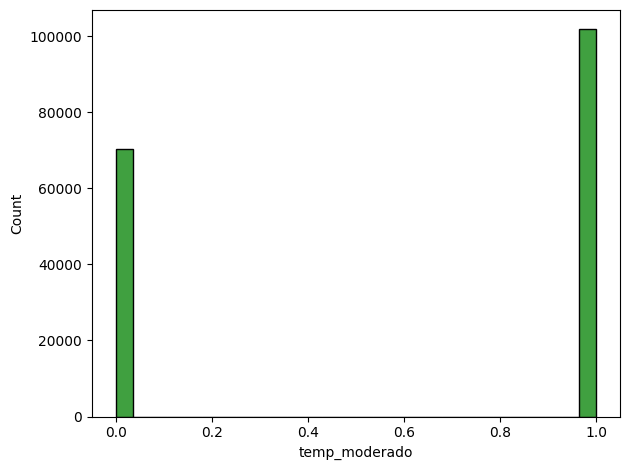

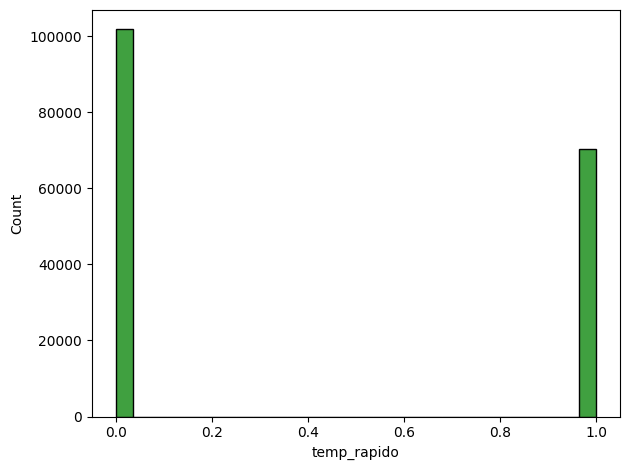

In [310]:
numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
newdf = df.select_dtypes(include=numerics)
l = [x for x in newdf.columns.values if not 'key' in x] 

a=0

for name in l:
    try:
        i,j = divmod(a, 10)
        sns.histplot(x = newdf[name] ,  color='green')
        plt.tight_layout()
        plt.show()
        a += 1
    except:
        pass

